# **env Setup**

In [1]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
import kagglehub
dhoogla_cicids2017_path = kagglehub.dataset_download('dhoogla/cicids2017')

print('Data source import complete.')


Data source import complete.


In [2]:
# ───────────────────────────────────────────────────────────────────────────────
# DYNAMIC ENVIRONMENT SETUP FOR MULTIPLE GPU/TPU CONFIGURATIONS
# ───────────────────────────────────────────────────────────────────────────────

import os, random, warnings

# 1) GPU/TPU CONFIGURATION
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'  # Suppress TF info messages
warnings.filterwarnings("ignore", category=UserWarning)

import tensorflow as tf
import pandas as pd
import numpy as np

# Improved hardware detection
try:
    # First try TPU detection
    tpu = tf.distribute.cluster_resolver.TPUClusterResolver()
    tf.config.experimental_connect_to_cluster(tpu)
    tf.tpu.experimental.initialize_tpu_system(tpu)
    strategy = tf.distribute.TPUStrategy(tpu)
    device_type = 'TPU'
    print(f"✅ Using TPU: {tpu.master()}")
except (ValueError, tf.errors.NotFoundError):
    # If TPU not found, check for GPUs
    gpus = tf.config.list_physical_devices('GPU')
    if gpus:
        # Use all available GPUs
        strategy = tf.distribute.MirroredStrategy()
        device_type = 'GPU'
        print(f"✅ Using {len(gpus)} GPU(s)")
    else:
        # Fallback to CPU
        strategy = tf.distribute.get_strategy()
        device_type = 'CPU'
        print("✅ Using CPU")

print("Visible devices:", tf.config.get_visible_devices())

# 2) PRECISION CONFIGURATION
from tensorflow.keras import mixed_precision

if device_type == 'TPU':
    policy = mixed_precision.Policy('mixed_bfloat16')
    mixed_precision.set_global_policy(policy)
    print(f"✅ Precision: mixed_bfloat16 (required for TPU)")
elif any('gpu' in d.device_type.lower() for d in tf.config.get_visible_devices()):
    policy = mixed_precision.Policy('mixed_float16')
    mixed_precision.set_global_policy(policy)
    print(f"✅ Precision: mixed_float16")
else:
    print("✅ Precision: float32 (CPU mode)")

# 3) GPU MEMORY MANAGEMENT (skip for TPU)
if device_type == 'GPU':
    for gpu in tf.config.list_physical_devices('GPU'):
        try:
            tf.config.experimental.set_memory_growth(gpu, True)
        except:
            pass

    
# 4) PERFORMANCE OPTIMIZATIONS
# Enable XLA compilation
tf.config.optimizer.set_jit(True)

# Configure dataset pipeline
options = tf.data.Options()
options.experimental_optimization.parallel_batch = True
options.threading.private_threadpool_size = min(8, os.cpu_count() or 8)

# 5) REPRODUCIBILITY
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# ─── PYDATA & ML LIBRARIES ─────────────────────────────────────────────────────

from sklearn.model_selection      import train_test_split
from sklearn.feature_selection    import VarianceThreshold, SelectFromModel
from sklearn.ensemble             import RandomForestClassifier
from sklearn.preprocessing        import StandardScaler, QuantileTransformer, LabelEncoder
from sklearn.decomposition        import PCA
from sklearn.utils                import resample, class_weight
from sklearn.metrics              import (
    classification_report, confusion_matrix,
    roc_auc_score, precision_recall_curve, roc_curve,
    mean_squared_error, mean_absolute_error, r2_score
)
from sklearn.manifold             import TSNE

# Optional UMAP embedding
try:
    from umap import UMAP
    print("✅ UMAP imported")
except ImportError:
    print("⚠️ UMAP not available")

# ─── DEEP LEARNING UTILITIES ───────────────────────────────────────────────────
from tensorflow.keras             import layers, models, optimizers, callbacks
from tensorflow.data              import Dataset
from tensorflow.python.framework  import convert_to_constants

# ─── IMAGE / AUTOENCODER METRICS ───────────────────────────────────────────────
# Correct installation and import of scikit-image
try:
    from skimage.metrics import peak_signal_noise_ratio as psnr
    from skimage.metrics import structural_similarity as ssim
    print("✅ scikit-image metrics imported")
except ImportError:
    print("Installing scikit-image for image metrics...")
    import sys
    import subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "scikit-image"])
    from skimage.metrics import peak_signal_noise_ratio as psnr
    from skimage.metrics import structural_similarity as ssim
    print("✅ scikit-image installed and imported")

# ─── PLOTTING ──────────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt

print(f"✅ Environment configured | TensorFlow {tf.__version__} | Device: {device_type}")

warnings.filterwarnings("ignore")
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

import tensorflow as tf
print(tf.__version__)

# XGBoost
import xgboost as xgb

2026-03-24 15:07:41.083744: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1774364861.264152      24 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1774364861.322719      24 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1774364861.738938      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774364861.738999      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774364861.739002      24 computation_placer.cc:177] computation placer alr

INFO:tensorflow:Using MirroredStrategy with devices ('/job:localhost/replica:0/task:0/device:GPU:0',)
✅ Using 1 GPU(s)
Visible devices: [PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU'), PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
✅ Precision: mixed_float16


I0000 00:00:1774364885.118589      24 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


✅ UMAP imported
✅ scikit-image metrics imported
✅ Environment configured | TensorFlow 2.19.0 | Device: GPU
2.19.0


# **Data Loading**

In [3]:
import os
import pandas as pd

BASE_PATH = "/kaggle/input/notebooks/yacermeftah/cicids-dataset-processing/cicids2017_processed"

import json

with open(f"{BASE_PATH}/manifest.json") as f:
    manifest = json.load(f)

train_df = pd.read_parquet(f"{BASE_PATH}/data/train_processed.parquet")
test_df  = pd.read_parquet(f"{BASE_PATH}/data/test_processed.parquet")

print(train_df.shape, test_df.shape)

(1850977, 35) (462745, 35)


In [4]:
manifest

{'train_file': '/kaggle/working/cicids2017_processed/data/train_processed.parquet',
 'test_file': '/kaggle/working/cicids2017_processed/data/test_processed.parquet',
 'label_encoder': '/kaggle/working/cicids2017_processed/artifacts/label_encoder.joblib',
 'scaler': '/kaggle/working/cicids2017_processed/artifacts/scaler.joblib',
 'variance_selector': '/kaggle/working/cicids2017_processed/artifacts/variance_selector.joblib',
 'settings': '/kaggle/working/cicids2017_processed/artifacts/preprocess_settings.json'}

In [5]:
X_train = train_df.drop(columns=["LabelEncoded"])
y_train = train_df["LabelEncoded"]

X_test = test_df.drop(columns=["LabelEncoded"])
y_test = test_df["LabelEncoded"]

In [6]:
import joblib

scaler = joblib.load(f"{BASE_PATH}/artifacts/scaler.joblib")
label_encoder = joblib.load(f"{BASE_PATH}/artifacts/label_encoder.joblib")
variance_selector = joblib.load(f"{BASE_PATH}/artifacts/variance_selector.joblib")

In [7]:
with open(f"{BASE_PATH}/artifacts/preprocess_settings.json") as f:
    settings = json.load(f)

settings

{'seed': 42,
 'test_size': 0.2,
 'rare_threshold_pct': 0.1,
 'eps': 1e-06,
 'feature_selection': {'variance_threshold': 0.001,
  'correlation_threshold': 0.9,
  'selected_features': ['Bwd Packet Length Max',
   'Flow IAT Std',
   'Flow Packets/s',
   'Fwd Packet Length Max',
   'Fwd Packets Length Total',
   'Packet_Entropy',
   'Bwd Packets/s',
   'Fwd Packet Length Mean',
   'Fwd Header Length',
   'Flow IAT Mean',
   'Init Bwd Win Bytes',
   'Bwd Header Length',
   'Total Fwd Packets',
   'Fwd Act Data Packets',
   'Burst_Ratio',
   'Flow Duration',
   'Init Fwd Win Bytes',
   'Flow Bytes/s',
   'Active Max',
   'Fwd IAT Min',
   'FIN Flag Count',
   'Active Mean',
   'Bwd IAT Std',
   'Fwd Packet Length Min',
   'Bwd IAT Total',
   'Bwd Packet Length Min',
   'Packet Length Min',
   'Bwd IAT Max',
   'Bwd IAT Mean',
   'Flow IAT Min',
   'Fwd Seg Size Min',
   'Down/Up Ratio',
   'ACK Flag Count',
   'Active Std']},
 'balancing': {'resample_config': {'Benign': 0.5,
   'DoS Hulk': 2

In [8]:
train_labels_original = pd.read_parquet(f"{BASE_PATH}/data/train_labels_original.parquet")
test_labels_original  = pd.read_parquet(f"{BASE_PATH}/data/test_labels_original.parquet")

In [9]:
print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

print("Scaler expects:", scaler.n_features_in_)

Train shape: (1850977, 34)
Test shape: (462745, 34)
Scaler expects: 34


In [10]:
# Scale first
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Benign label from your saved mapping
benign_label = settings["label_mapping"]["Benign"]  # usually 0

# Create benign mask from encoded labels
benign_mask = (y_train == benign_label)

# Extract benign samples
X_benign = X_train_scaled[benign_mask].astype(np.float32)

# Sanity check
print(X_benign.shape)

(1581783, 34)


In [11]:
import json
import joblib
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

base_PATH = "/kaggle/input/notebooks/yacermeftah/intrusion-detection-with-vae/"
MODEL_PATH = "vae_cicids.keras"
THRESHOLD_PATH = "vae_threshold.joblib"
SCALER_PATH = "vae_scaler.joblib"
CONFIG_PATH = "vae_config.json"
HISTORY_PATH = "vae_history.joblib"

In [12]:
@tf.keras.utils.register_keras_serializable()
class Sampling(layers.Layer):
    def __init__(self, kl_weight=1.0, **kwargs):
        super().__init__(**kwargs)
        self.kl_weight = tf.Variable(
            initial_value=float(kl_weight),
            trainable=False,
            dtype=tf.float32
        )

    def call(self, inputs, training=None):
        z_mean, z_log_var = inputs
        z_mean = tf.cast(z_mean, tf.float32)
        z_log_var = tf.cast(z_log_var, tf.float32)
        z_log_var = tf.clip_by_value(z_log_var, -20.0, 10.0)

        kl_element = -0.5 * (1.0 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var))
        kl_loss = tf.reduce_mean(tf.reduce_sum(kl_element, axis=1))
        self.add_loss(self.kl_weight * 0.01 * kl_loss)

        if training:
            eps = tf.random.normal(tf.shape(z_mean), dtype=tf.float32)
            return z_mean + tf.exp(0.5 * z_log_var) * eps
        return z_mean

    def get_config(self):
        config = super().get_config()
        config.update({"kl_weight": float(self.kl_weight.numpy())})
        return config

    @classmethod
    def from_config(cls, config):
        return cls(**config)

In [13]:
@tf.keras.utils.register_keras_serializable()
class FeatureWeightedLoss(layers.Layer):
    def __init__(self, feature_weights, **kwargs):
        super().__init__(**kwargs)
        w = np.asarray(feature_weights, dtype=np.float32)

        # Normalize weights so the average weight is ~1
        w = w / (np.mean(w) + 1e-8)

        # Clip extreme weights to avoid one feature dominating
        w = np.clip(w, 0.1, 10.0)

        self.feature_weights = tf.constant(w, dtype=tf.float32)

    def call(self, inputs, reconstructions):
        inputs = tf.cast(inputs, tf.float32)
        reconstructions = tf.cast(reconstructions, tf.float32)

        squared_diff = tf.square(inputs - reconstructions)
        weighted_loss = tf.reduce_mean(squared_diff * self.feature_weights, axis=-1)
        return tf.reduce_mean(weighted_loss)

In [14]:
@tf.keras.utils.register_keras_serializable()
class VAE(tf.keras.Model):
    def __init__(self, input_dim=34, latent_dim=16, **kwargs):
        super().__init__(**kwargs)
        self.input_dim = int(input_dim)
        self.latent_dim = int(latent_dim)

        self.encoder_dense0 = layers.Dense(256)
        self.encoder_bn0 = layers.BatchNormalization()
        self.encoder_act0 = layers.LeakyReLU()

        self.encoder_dense1 = layers.Dense(128)
        self.encoder_bn1 = layers.BatchNormalization()
        self.encoder_act1 = layers.LeakyReLU()

        self.encoder_dense2 = layers.Dense(64)
        self.encoder_bn2 = layers.BatchNormalization()
        self.encoder_act2 = layers.LeakyReLU()

        self.z_mean_layer = layers.Dense(latent_dim, name="z_mean")
        self.z_log_var_layer = layers.Dense(latent_dim, name="z_log_var")
        self.sampling = Sampling(name="sampling")

        self.decoder_dense1 = layers.Dense(64)
        self.decoder_bn1 = layers.BatchNormalization()
        self.decoder_act1 = layers.LeakyReLU()

        self.decoder_dense2 = layers.Dense(128)
        self.decoder_bn2 = layers.BatchNormalization()
        self.decoder_act2 = layers.LeakyReLU()

        self.decoder_dense3 = layers.Dense(256)
        self.decoder_bn3 = layers.BatchNormalization()
        self.decoder_act3 = layers.LeakyReLU()

        self.decoder_output = layers.Dense(self.input_dim, activation="linear", name="decoder_output")

    def call(self, inputs, training=None):
        x = self.encoder_dense0(inputs)
        x = self.encoder_bn0(x, training=training)
        x = self.encoder_act0(x)

        x = self.encoder_dense1(x)
        x = self.encoder_bn1(x, training=training)
        x = self.encoder_act1(x)

        x = self.encoder_dense2(x)
        x = self.encoder_bn2(x, training=training)
        x = self.encoder_act2(x)

        z_mean = self.z_mean_layer(x)
        z_log_var = self.z_log_var_layer(x)
        z = self.sampling((z_mean, z_log_var), training=training)

        x = self.decoder_dense1(z)
        x = self.decoder_bn1(x, training=training)
        x = self.decoder_act1(x)

        x = self.decoder_dense2(x)
        x = self.decoder_bn2(x, training=training)
        x = self.decoder_act2(x)

        x = self.decoder_dense3(x)
        x = self.decoder_bn3(x, training=training)
        x = self.decoder_act3(x)

        return self.decoder_output(x)

    def get_config(self):
        config = super().get_config()
        config.update({
            "input_dim": self.input_dim,
            "latent_dim": self.latent_dim,
        })
        return config

    @classmethod
    def from_config(cls, config):
        return cls(**config)

In [15]:
vae = keras.models.load_model(
    base_PATH + "vae_cicids.keras",
    custom_objects={
        "VAE": VAE,
        "Sampling": Sampling,
    },
    compile=False
)

history = joblib.load(base_PATH + HISTORY_PATH)

threshold = joblib.load(base_PATH + "vae_threshold.joblib")
scaler = joblib.load(base_PATH + "vae_scaler.joblib")

with open(base_PATH + "vae_config.json", "r") as f:
    config = json.load(f)

num_features = config["input_dim"]
latent_dim = config["latent_dim"]
features = config["features"]
scaling = config["scaling"]
seed = config["seed"]

print("Model and artifacts loaded successfully.")
print("Threshold:", threshold)
print("Input dim:", num_features)
print("Latent dim:", latent_dim)
print("Number of features:", len(features))

Model and artifacts loaded successfully.
Threshold: 2.138385057449341
Input dim: 34
Latent dim: 16
Number of features: 34


# **Modeling**

In [16]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_sample_weight
from lightgbm import LGBMClassifier, early_stopping, log_evaluation

In [17]:
class VAEGatedMultiClassSystem:
    def __init__(
        self,
        vae,
        scaler,
        benign_label,
        feature_names,
        id_to_label,
        accept_quantile=0.99,
        random_state=42,
    ):
        self.vae = vae
        self.scaler = scaler
        self.benign_label = benign_label
        self.feature_names = list(feature_names)
        self.id_to_label = dict(id_to_label)
        self.accept_quantile = float(accept_quantile)
        self.random_state = int(random_state)

        self.accept_threshold = None
        self.booster = None

    def _scale(self, X):
        if isinstance(X, pd.DataFrame):
            X = X[self.feature_names].values
        return self.scaler.transform(X).astype(np.float32)

    def _recon_error(self, X_scaled, batch_size=8192):
        X_hat = self.vae.predict(X_scaled, batch_size=batch_size, verbose=0)
        X_hat = np.asarray(X_hat, dtype=np.float32)
        return np.mean(np.square(X_scaled - X_hat), axis=1)

    def _augment(self, X_scaled, recon_error):
        recon_error = np.asarray(recon_error, dtype=np.float32).reshape(-1, 1)
        return np.hstack([X_scaled.astype(np.float32), recon_error])

    def fit_gate(self, X_benign_calibration):
        Xb = self._scale(X_benign_calibration)
        scores = self._recon_error(Xb)
        self.accept_threshold = float(np.quantile(scores, self.accept_quantile))
        return self

    def fit_booster(self, X_train, y_train, X_val=None, y_val=None):
        X_train_scaled = self._scale(X_train)
        train_scores = self._recon_error(X_train_scaled)
        X_train_aug = self._augment(X_train_scaled, train_scores)

        y_train = np.asarray(y_train).astype(int)
        train_weight = compute_sample_weight(class_weight="balanced", y=y_train)

        if X_val is not None and y_val is not None:
            X_val_scaled = self._scale(X_val)
            val_scores = self._recon_error(X_val_scaled)
            X_val_aug = self._augment(X_val_scaled, val_scores)
            y_val = np.asarray(y_val).astype(int)
            val_weight = compute_sample_weight(class_weight="balanced", y=y_val)
        else:
            X_val_aug = None
            y_val = None
            val_weight = None

        n_classes = len(np.unique(y_train))

        self.booster = LGBMClassifier(
            objective="multiclass",
            num_class=len(np.unique(y_train)),
            n_estimators=5000,
            learning_rate=0.03,
            num_leaves=63,
            max_depth=-1,
            min_child_samples=40,
            subsample=0.85,
            colsample_bytree=0.85,
            reg_alpha=0.0,
            reg_lambda=1.0,
            random_state=42,
            n_jobs=-1,
            verbosity=-1,      # silences info/warnings
            force_col_wise=True # removes the auto-tuning overhead message
        )

        fit_kwargs = {}
        if X_val_aug is not None:
                fit_kwargs["eval_set"] = [(X_val_aug, y_val)]
                fit_kwargs["eval_sample_weight"] = [val_weight]
                fit_kwargs["callbacks"] = [early_stopping(100), log_evaluation(100)]

        self.booster.fit(
                X_train_aug,
                y_train,
                sample_weight=train_weight,
                **fit_kwargs,
        )

        return self

    def predict(self, X, return_stage=False):
        if self.accept_threshold is None:
            raise ValueError("Gate threshold is not set. Call fit_gate(...) first.")
        if self.booster is None:
            raise ValueError("Booster is not trained. Call fit_booster(...) first.")

        X_scaled = self._scale(X)
        scores = self._recon_error(X_scaled)
        route_to_booster = scores > self.accept_threshold

        y_pred = np.full(shape=(len(X_scaled),), fill_value=self.benign_label, dtype=np.int64)
        stage = np.array(["vae-benign"] * len(X_scaled), dtype=object)

        if np.any(route_to_booster):
            X_aug = self._augment(X_scaled[route_to_booster], scores[route_to_booster])
            booster_pred = self.booster.predict(X_aug)

            y_pred[route_to_booster] = np.asarray(booster_pred).astype(np.int64)
            stage[route_to_booster] = "booster"

        if return_stage:
            return y_pred, stage, scores
        return y_pred

    def predict_proba(self, X):
        if self.accept_threshold is None:
            raise ValueError("Gate threshold is not set. Call fit_gate(...) first.")
        if self.booster is None:
            raise ValueError("Booster is not trained. Call fit_booster(...) first.")

        X_scaled = self._scale(X)
        scores = self._recon_error(X_scaled)
        route_to_booster = scores > self.accept_threshold

        n_classes = len(self.id_to_label)
        proba = np.zeros((len(X_scaled), n_classes), dtype=np.float32)
        proba[:, self.benign_label] = 1.0

        if np.any(route_to_booster):
            X_aug = self._augment(X_scaled[route_to_booster], scores[route_to_booster])
            booster_proba = self.booster.predict_proba(X_aug)
            proba[route_to_booster] = booster_proba.astype(np.float32)

        return proba

    def save(self, out_dir):
        import os
        os.makedirs(out_dir, exist_ok=True)
        joblib.dump(self.booster, os.path.join(out_dir, "booster.joblib"))
        joblib.dump(self.accept_threshold, os.path.join(out_dir, "accept_threshold.joblib"))
        with open(os.path.join(out_dir, "system_config.json"), "w") as f:
            json.dump(
                {
                    "accept_quantile": self.accept_quantile,
                    "random_state": self.random_state,
                    "benign_label": int(self.benign_label),
                    "feature_names": self.feature_names,
                    "id_to_label": self.id_to_label,
                },
                f,
                indent=4,
            )

    @classmethod
    def load(cls, vae, scaler, out_dir):
        import os
        with open(os.path.join(out_dir, "system_config.json"), "r") as f:
            cfg = json.load(f)

        system = cls(
            vae=vae,
            scaler=scaler,
            benign_label=cfg["benign_label"],
            feature_names=cfg["feature_names"],
            id_to_label={int(k): v for k, v in cfg["id_to_label"].items()},
            accept_quantile=cfg["accept_quantile"],
            random_state=cfg["random_state"],
        )
        system.booster = joblib.load(os.path.join(out_dir, "booster.joblib"))
        system.accept_threshold = joblib.load(os.path.join(out_dir, "accept_threshold.joblib"))
        return system

In [18]:
benign_label = settings["label_mapping"]["Benign"]
id_to_label = {v: k for k, v in settings["label_mapping"].items()}
feature_names = settings["feature_selection"]["selected_features"]

X_all = train_df.drop(columns=["LabelEncoded"])
y_all = train_df["LabelEncoded"].astype(int)

X_train_main, X_cal, y_train_main, y_cal = train_test_split(
    X_all,
    y_all,
    test_size=0.15,
    random_state=42,
    stratify=y_all
)

In [19]:
system = VAEGatedMultiClassSystem(
    vae=vae,
    scaler=scaler,
    benign_label=benign_label,
    feature_names=feature_names,
    id_to_label=id_to_label,
    accept_quantile=0.99,   # conservative benign acceptance
    random_state=42,
)

In [20]:
# Gate calibration: use benign rows only
cal_benign_mask = (y_cal.values == benign_label)
system.fit_gate(X_cal.loc[cal_benign_mask])

# Booster training: all classes
system.fit_booster(
    X_train_main,
    y_train_main,
    X_val=X_cal,
    y_val=y_cal
)

print("VAE accept threshold:", system.accept_threshold)

I0000 00:00:1774364931.613143      67 service.cc:152] XLA service 0x795884004000 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1774364931.613179      67 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1774364931.743158      67 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1774364932.345341      67 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


Training until validation scores don't improve for 100 rounds
[100]	valid_0's multi_logloss: 0.0254667
[200]	valid_0's multi_logloss: 0.0223071
Early stopping, best iteration is:
[139]	valid_0's multi_logloss: 0.0205536
VAE accept threshold: 0.5301672220230103


# **Evaluation**

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_curve,
    auc,
    roc_auc_score,
    average_precision_score,
    precision_recall_curve,
    log_loss,
)

sns.set_theme(style="whitegrid")

In [22]:
def drop_label_if_present(X):
    if isinstance(X, pd.DataFrame) and "LabelEncoded" in X.columns:
        return X.drop(columns=["LabelEncoded"])
    return X

def to_encoded_labels(y):
    y = np.asarray(y)
    if y.dtype.kind in {"U", "S", "O"}:
        return label_encoder.transform(y)
    return y.astype(int)

def get_class_names(id_to_label, labels):
    return [id_to_label[int(i)] for i in labels]

def plot_confusion_matrix(cm, class_names, title):
    plt.figure(figsize=(11, 8))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=class_names,
        yticklabels=class_names,
        cbar=False,
    )
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.xticks(rotation=45, ha="right")
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

In [23]:
def plot_class_f1(report_dict, class_names, title):
    rows = []
    for cls in class_names:
        if cls in report_dict:
            rows.append({
                "class": cls,
                "precision": report_dict[cls]["precision"],
                "recall": report_dict[cls]["recall"],
                "f1-score": report_dict[cls]["f1-score"],
            })
    df = pd.DataFrame(rows).melt(id_vars="class", var_name="metric", value_name="value")
    plt.figure(figsize=(12, 5))
    sns.barplot(data=df, x="class", y="value", hue="metric")
    plt.title(title)
    plt.xlabel("")
    plt.ylabel("Score")
    plt.xticks(rotation=45, ha="right")
    plt.ylim(0, 1.05)
    plt.tight_layout()
    plt.show()

In [24]:
def plot_recon_error_distribution(scores, y_true, benign_label, id_to_label, sample_size=50000):
    n = len(scores)
    if n > sample_size:
        idx = np.random.default_rng(42).choice(n, size=sample_size, replace=False)
        scores_plot = scores[idx]
        y_plot = y_true[idx]
    else:
        scores_plot = scores
        y_plot = y_true

    df = pd.DataFrame({
        "reconstruction_error": scores_plot,
        "group": np.where(y_plot == benign_label, "Benign", "Attack")
    })

    plt.figure(figsize=(10, 5))
    sns.histplot(
        data=df,
        x="reconstruction_error",
        hue="group",
        stat="density",
        common_norm=False,
        bins=60,
        element="step",
        kde=True
    )
    plt.title("VAE Reconstruction Error Distribution")
    plt.xlabel("Mean Squared Reconstruction Error")
    plt.ylabel("Density")
    plt.tight_layout()
    plt.show()

In [25]:
def plot_binary_roc_pr(y_bin, scores, title_prefix):
    fpr, tpr, _ = roc_curve(y_bin, scores)
    roc_auc = auc(fpr, tpr)
    ap = average_precision_score(y_bin, scores)

    plt.figure(figsize=(7, 6))
    plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
    plt.plot([0, 1], [0, 1], linestyle="--")
    plt.title(f"{title_prefix} ROC Curve")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.legend(loc="lower right")
    plt.tight_layout()
    plt.show()

    precision, recall, _ = precision_recall_curve(y_bin, scores)
    plt.figure(figsize=(7, 6))
    plt.plot(recall, precision, label=f"AP = {ap:.4f}")
    plt.title(f"{title_prefix} Precision-Recall Curve")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.legend(loc="lower left")
    plt.tight_layout()
    plt.show()

def safe_multiclass_roc_auc(y_true, proba):
    try:
        return roc_auc_score(y_true, proba, multi_class="ovr", average="macro")
    except Exception:
        return np.nan

In [26]:
def evaluate_vae(vae, X, y, scaler, benign_label, id_to_label):
    X = drop_label_if_present(X)
    y = to_encoded_labels(y)

    X_scaled = scaler.transform(X).astype(np.float32)
    recon = vae.predict(X_scaled, batch_size=8192, verbose=0).astype(np.float32)
    scores = np.mean(np.square(X_scaled - recon), axis=1)

    y_bin = (y != benign_label).astype(int)

    threshold = system.accept_threshold if hasattr(system, "accept_threshold") else None
    if threshold is not None:
        y_pred_bin = (scores > threshold).astype(int)
    else:
        y_pred_bin = (scores > np.quantile(scores, 0.99)).astype(int)

    report = {
        "accuracy": accuracy_score(y_bin, y_pred_bin),
        "balanced_accuracy": balanced_accuracy_score(y_bin, y_pred_bin),
        "precision": precision_score(y_bin, y_pred_bin, zero_division=0),
        "recall": recall_score(y_bin, y_pred_bin, zero_division=0),
        "f1": f1_score(y_bin, y_pred_bin, zero_division=0),
        "roc_auc": roc_auc_score(y_bin, scores),
        "average_precision": average_precision_score(y_bin, scores),
        "mean_recon_error_benign": float(np.mean(scores[y == benign_label])),
        "mean_recon_error_attack": float(np.mean(scores[y != benign_label])),
    }

    print("\nVAE evaluation")
    print(pd.Series(report).to_string())

    plot_recon_error_distribution(scores, y, benign_label, id_to_label)
    plot_binary_roc_pr(y_bin, scores, "VAE")

    return report, scores

In [27]:
def evaluate_booster(system, X, y, id_to_label):
    X = drop_label_if_present(X)
    y = to_encoded_labels(y)

    X_scaled = system._scale(X)
    recon_scores = system._recon_error(X_scaled)
    X_aug = system._augment(X_scaled, recon_scores)

    y_pred = system.booster.predict(X_aug)
    y_proba = system.booster.predict_proba(X_aug)

    labels = np.array(sorted(np.unique(np.concatenate([y, y_pred]))))
    class_names = get_class_names(id_to_label, labels)

    report_dict = classification_report(
        y, y_pred, labels=labels, target_names=class_names, output_dict=True, zero_division=0
    )

    summary = {
        "accuracy": accuracy_score(y, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y, y_pred),
        "macro_f1": f1_score(y, y_pred, average="macro", zero_division=0),
        "weighted_f1": f1_score(y, y_pred, average="weighted", zero_division=0),
        "macro_precision": precision_score(y, y_pred, average="macro", zero_division=0),
        "macro_recall": recall_score(y, y_pred, average="macro", zero_division=0),
        "log_loss": log_loss(y, y_proba, labels=labels),
        "roc_auc_ovr_macro": safe_multiclass_roc_auc(y, y_proba),
    }

    print("\nLightGBM standalone evaluation")
    print(pd.Series(summary).to_string())

    cm = confusion_matrix(y, y_pred, labels=labels)
    plot_confusion_matrix(cm, class_names, "LightGBM Standalone Confusion Matrix")
    plot_class_f1(report_dict, class_names, "LightGBM Standalone Per-Class Metrics")

    return summary, y_pred, y_proba, report_dict

In [28]:
def evaluate_overall_system(system, X, y, id_to_label):
    X = drop_label_if_present(X)
    y = to_encoded_labels(y)

    y_pred, stage, scores = system.predict(X, return_stage=True)
    proba = system.predict_proba(X)

    labels = np.array(sorted(np.unique(np.concatenate([y, y_pred]))))
    class_names = get_class_names(id_to_label, labels)

    report_dict = classification_report(
        y, y_pred, labels=labels, target_names=class_names, output_dict=True, zero_division=0
    )

    summary = {
        "accuracy": accuracy_score(y, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y, y_pred),
        "macro_f1": f1_score(y, y_pred, average="macro", zero_division=0),
        "weighted_f1": f1_score(y, y_pred, average="weighted", zero_division=0),
        "macro_precision": precision_score(y, y_pred, average="macro", zero_division=0),
        "macro_recall": recall_score(y, y_pred, average="macro", zero_division=0),
        "log_loss": log_loss(y, proba, labels=labels),
        "roc_auc_ovr_macro": safe_multiclass_roc_auc(y, proba),
        "vae_gate_threshold": float(system.accept_threshold),
        "routed_to_booster_pct": float(np.mean(stage == "booster") * 100.0),
        "handled_by_vae_pct": float(np.mean(stage == "vae-benign") * 100.0),
    }

    print("\nOverall gated system evaluation")
    print(pd.Series(summary).to_string())

    cm = confusion_matrix(y, y_pred, labels=labels)
    plot_confusion_matrix(cm, class_names, "Overall Gated System Confusion Matrix")
    plot_class_f1(report_dict, class_names, "Overall Gated System Per-Class Metrics")

    # Route analysis
    route_df = pd.DataFrame({
        "stage": stage,
        "recon_error": scores,
    })

    plt.figure(figsize=(8, 5))
    sns.countplot(data=route_df, x="stage")
    plt.title("Routing Breakdown")
    plt.xlabel("Stage")
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(8, 5))
    sns.boxplot(data=route_df, x="stage", y="recon_error")
    plt.title("Reconstruction Error by Routing Stage")
    plt.xlabel("Stage")
    plt.ylabel("Reconstruction Error")
    plt.tight_layout()
    plt.show()

    return summary, y_pred, proba, stage, scores, report_dict


VAE evaluation
accuracy                   0.940179
balanced_accuracy          0.818747
precision                  0.916695
recall                     0.647508
f1                         0.758939
roc_auc                    0.954183
average_precision          0.855263
mean_recon_error_benign    0.058502
mean_recon_error_attack    1.024935


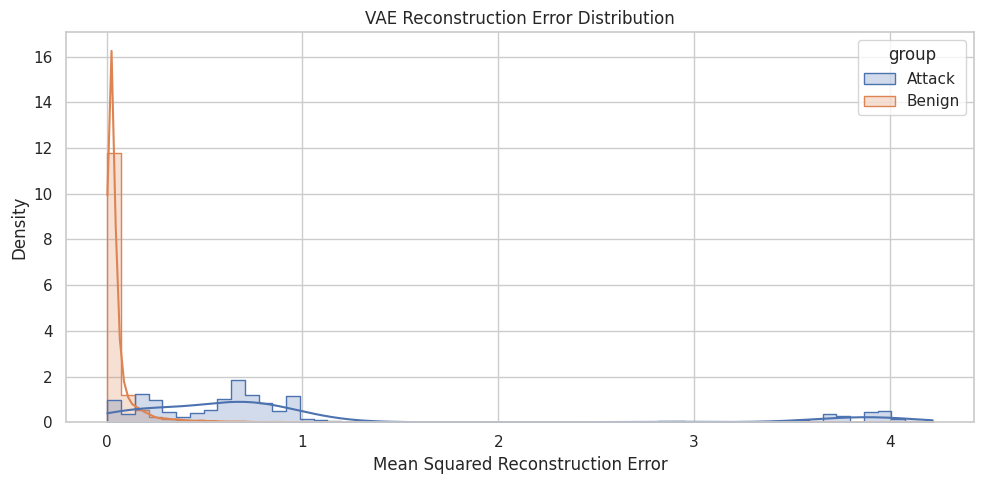

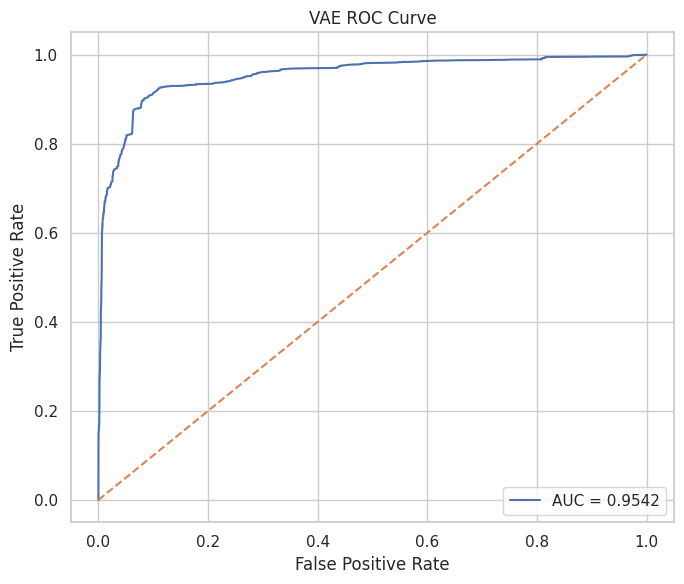

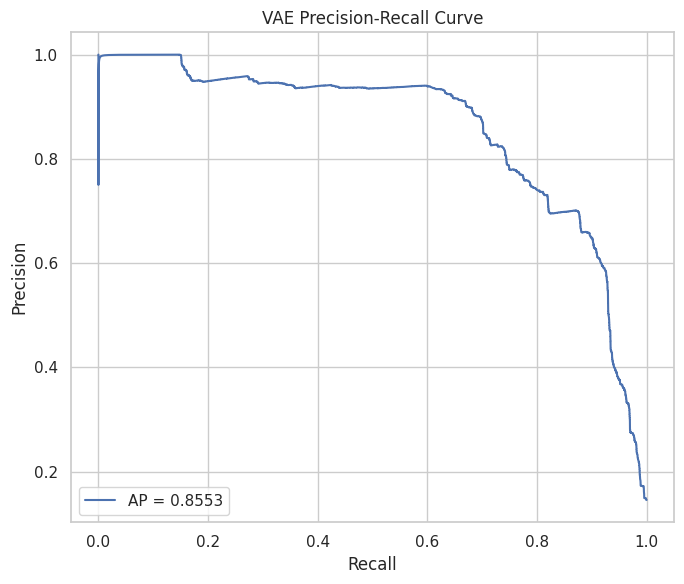

In [29]:
benign_label = settings["label_mapping"]["Benign"]

vae_report, vae_scores = evaluate_vae(
    vae=vae,
    X=X_test,
    y=y_test,
    scaler=scaler,
    benign_label=benign_label,
    id_to_label=id_to_label,
)


LightGBM standalone evaluation
accuracy             0.998163
balanced_accuracy    0.996333
macro_f1             0.969255
weighted_f1          0.998258
macro_precision      0.948059
macro_recall         0.996333
log_loss             0.010365
roc_auc_ovr_macro    0.999887


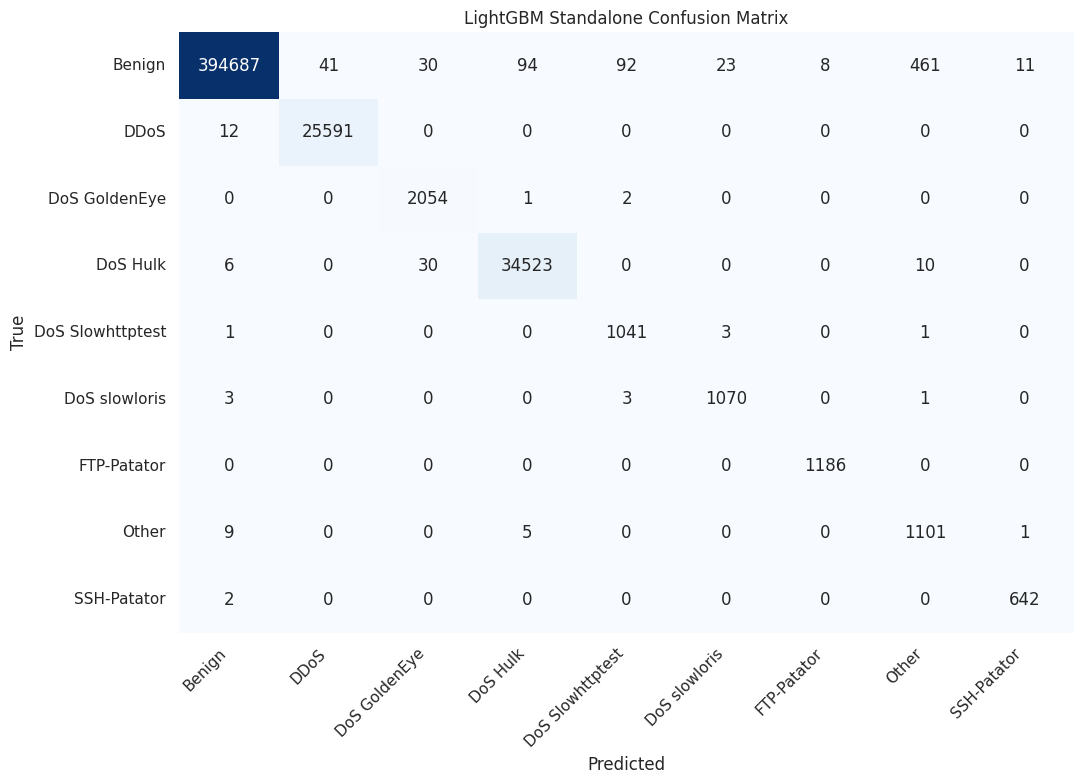

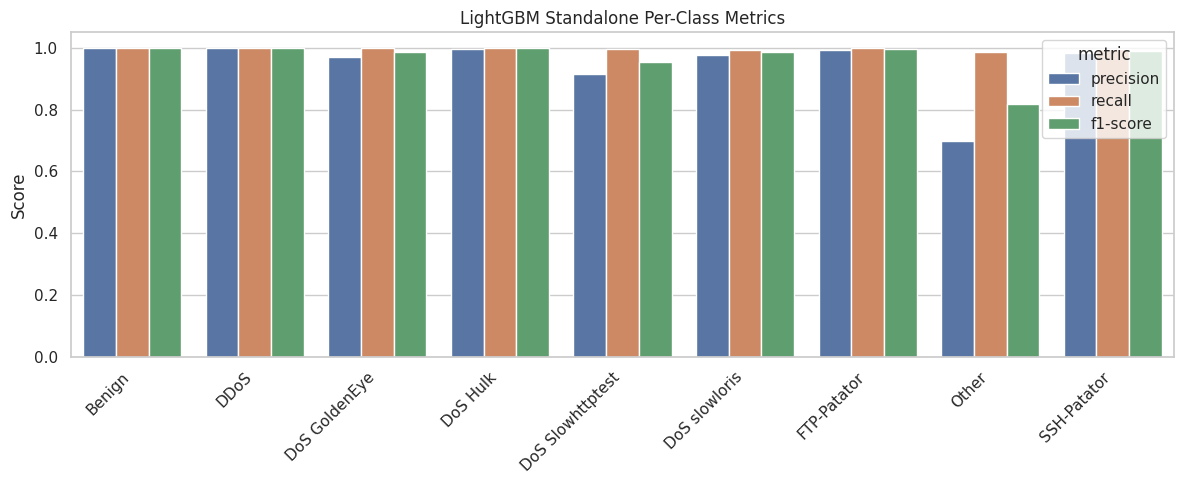

In [30]:
booster_report, booster_pred, booster_proba, booster_class_report = evaluate_booster(
    system=system,
    X=X_test,
    y=y_test,
    id_to_label=id_to_label,
)


Overall gated system evaluation
accuracy                  0.948615
balanced_accuracy         0.475928
macro_f1                  0.564360
weighted_f1               0.941338
macro_precision           0.977144
macro_recall              0.475928
log_loss                  0.817935
roc_auc_ovr_macro         0.692780
vae_gate_threshold        0.530167
routed_to_booster_pct    10.272612
handled_by_vae_pct       89.727388


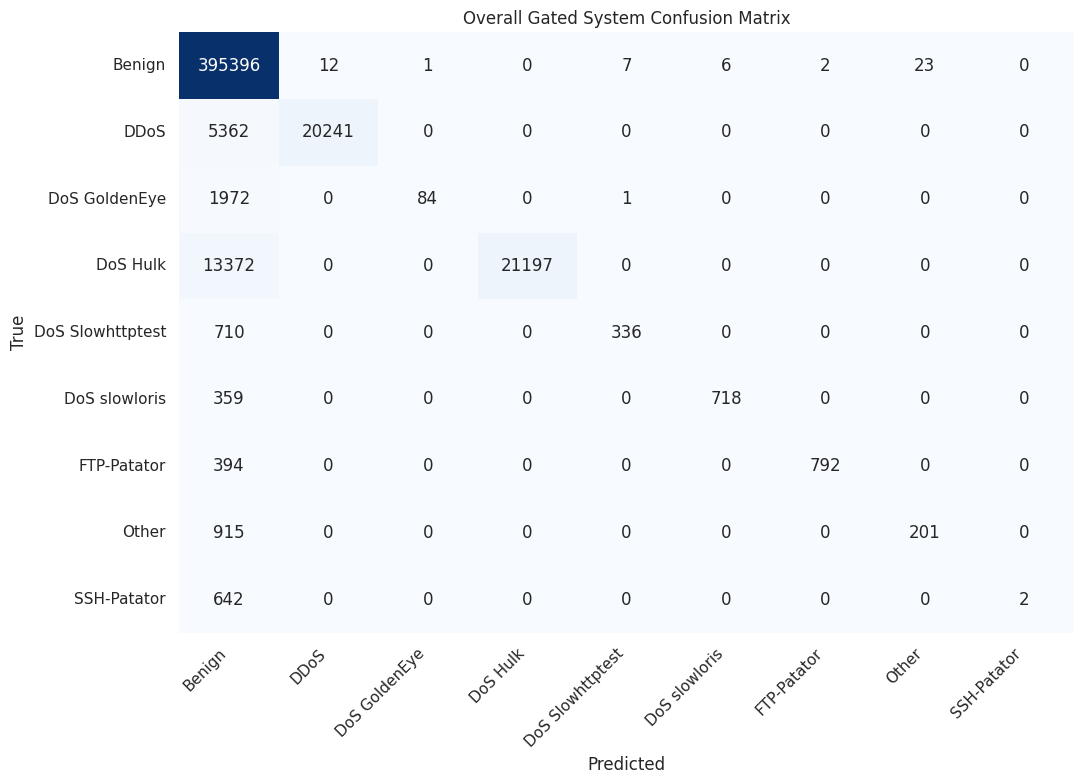

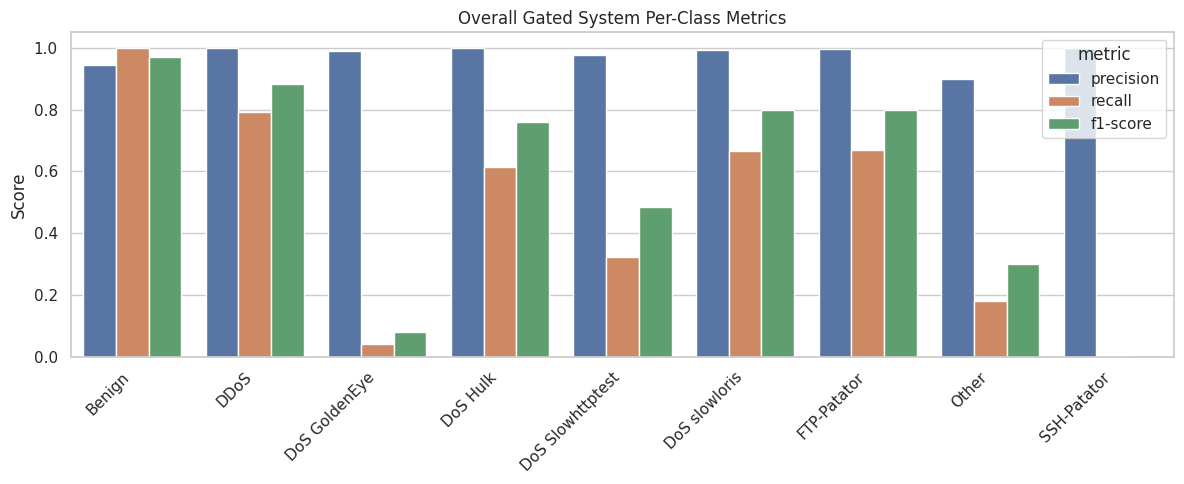

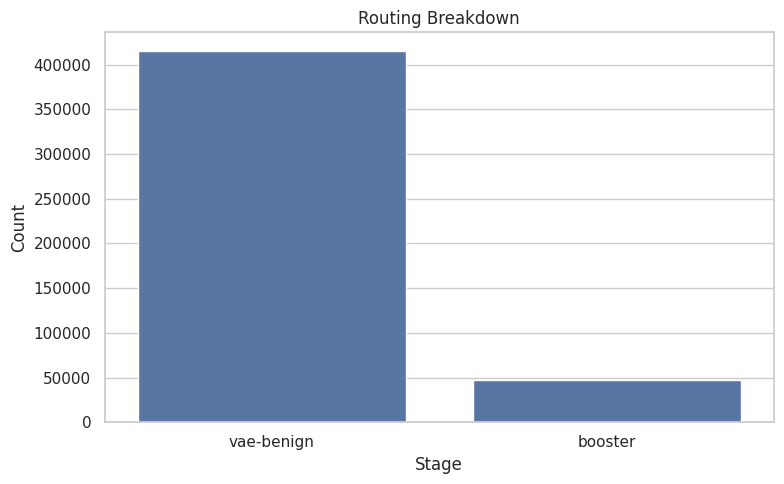

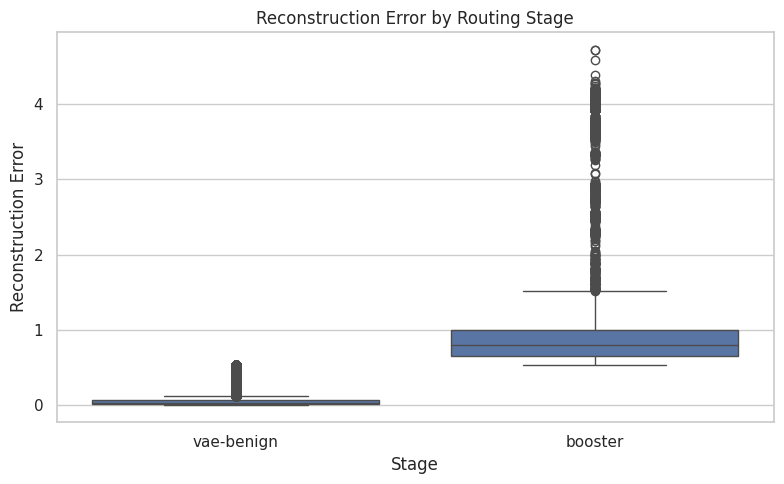

In [31]:
overall_report, overall_pred, overall_proba, overall_stage, overall_scores, overall_class_report = evaluate_overall_system(
    system=system,
    X=X_test,
    y=y_test,
    id_to_label=id_to_label,
)

In [32]:
summary_df = pd.DataFrame([
    {
        "model": "VAE",
        "accuracy": vae_report["accuracy"],
        "balanced_accuracy": vae_report["balanced_accuracy"],
        "macro_f1": np.nan,
        "weighted_f1": np.nan,
        "roc_auc_ovr_macro": vae_report["roc_auc"],
        "log_loss": np.nan,
        "handled_by_vae_pct": np.nan,
        "routed_to_booster_pct": np.nan,
    },
    {
        "model": "LightGBM standalone",
        "accuracy": booster_report["accuracy"],
        "balanced_accuracy": booster_report["balanced_accuracy"],
        "macro_f1": booster_report["macro_f1"],
        "weighted_f1": booster_report["weighted_f1"],
        "roc_auc_ovr_macro": booster_report["roc_auc_ovr_macro"],
        "log_loss": booster_report["log_loss"],
        "handled_by_vae_pct": np.nan,
        "routed_to_booster_pct": np.nan,
    },
    {
        "model": "Overall gated system",
        "accuracy": overall_report["accuracy"],
        "balanced_accuracy": overall_report["balanced_accuracy"],
        "macro_f1": overall_report["macro_f1"],
        "weighted_f1": overall_report["weighted_f1"],
        "roc_auc_ovr_macro": overall_report["roc_auc_ovr_macro"],
        "log_loss": overall_report["log_loss"],
        "handled_by_vae_pct": overall_report["handled_by_vae_pct"],
        "routed_to_booster_pct": overall_report["routed_to_booster_pct"],
    }
])

print("\nSummary comparison")
display(summary_df)


Summary comparison


,model,accuracy,balanced_accuracy,macro_f1,weighted_f1,roc_auc_ovr_macro,log_loss,handled_by_vae_pct,routed_to_booster_pct
0,VAE,0.940179,0.818747,NaN,NaN,0.954183,NaN,NaN,NaN
1,LightGBM standalone,0.998163,0.996333,0.969255,0.998258,0.999887,0.010365,NaN,NaN
2,Overall gated system,0.948615,0.475928,0.564360,0.941338,0.692780,0.817935,89.727388,10.272612


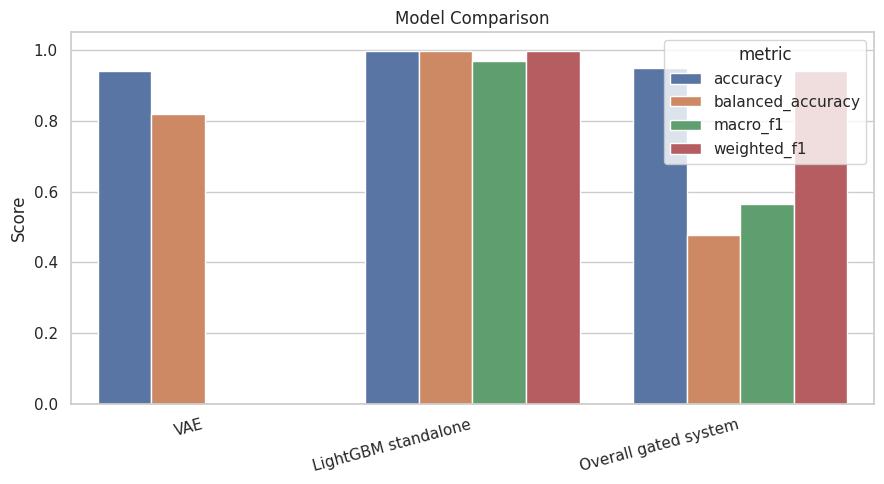

In [33]:
plt.figure(figsize=(9, 5))
plot_df = summary_df[["model", "accuracy", "balanced_accuracy", "macro_f1", "weighted_f1"]].melt(
    id_vars="model", var_name="metric", value_name="value"
)
sns.barplot(data=plot_df, x="model", y="value", hue="metric")
plt.title("Model Comparison")
plt.xlabel("")
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.show()

# **Save artifacts**

In [34]:
import os
import json
import joblib
import tensorflow as tf

SAVE_DIR = "/kaggle/working/cicids_vae_lgbm_bundle"
os.makedirs(SAVE_DIR, exist_ok=True)

# 1) Save the full gated system
system_dir = os.path.join(SAVE_DIR, "system")
system.save(system_dir)

# 2) Save the VAE model separately
vae_dir = os.path.join(SAVE_DIR, "vae")
os.makedirs(vae_dir, exist_ok=True)
vae.save(os.path.join(vae_dir, "vae_cicids.keras"))

# 3) Save preprocessing artifacts
artifacts_dir = os.path.join(SAVE_DIR, "artifacts")
os.makedirs(artifacts_dir, exist_ok=True)

joblib.dump(scaler, os.path.join(artifacts_dir, "scaler.joblib"))
joblib.dump(label_encoder, os.path.join(artifacts_dir, "label_encoder.joblib"))
joblib.dump(variance_selector, os.path.join(artifacts_dir, "variance_selector.joblib"))

# 4) Save config / metadata
metadata = {
    "seed": settings.get("seed", 42),
    "label_mapping": settings.get("label_mapping", {}),
    "feature_names": feature_names,
    "benign_label": benign_label,
    "accept_threshold": float(system.accept_threshold),
    "accept_quantile": float(system.accept_quantile),
    "input_dim": int(getattr(vae, "input_dim", 34)),
    "latent_dim": int(getattr(vae, "latent_dim", 16)),
    "tensorflow_version": tf.__version__,
}

with open(os.path.join(SAVE_DIR, "metadata.json"), "w") as f:
    json.dump(metadata, f, indent=4)

# 5) Save a simple manifest
manifest = {
    "system_dir": system_dir,
    "vae_model": os.path.join(vae_dir, "vae_cicids.keras"),
    "scaler": os.path.join(artifacts_dir, "scaler.joblib"),
    "label_encoder": os.path.join(artifacts_dir, "label_encoder.joblib"),
    "variance_selector": os.path.join(artifacts_dir, "variance_selector.joblib"),
    "metadata": os.path.join(SAVE_DIR, "metadata.json"),
}

with open(os.path.join(SAVE_DIR, "manifest.json"), "w") as f:
    json.dump(manifest, f, indent=4)

print("Saved successfully to:", SAVE_DIR)
print(json.dumps(manifest, indent=4))

Saved successfully to: /kaggle/working/cicids_vae_lgbm_bundle
{
    "system_dir": "/kaggle/working/cicids_vae_lgbm_bundle/system",
    "vae_model": "/kaggle/working/cicids_vae_lgbm_bundle/vae/vae_cicids.keras",
    "scaler": "/kaggle/working/cicids_vae_lgbm_bundle/artifacts/scaler.joblib",
    "label_encoder": "/kaggle/working/cicids_vae_lgbm_bundle/artifacts/label_encoder.joblib",
    "variance_selector": "/kaggle/working/cicids_vae_lgbm_bundle/artifacts/variance_selector.joblib",
    "metadata": "/kaggle/working/cicids_vae_lgbm_bundle/metadata.json"
}


**loading**

In [35]:
import json
import joblib
from tensorflow import keras

with open("/kaggle/working/cicids_vae_lgbm_bundle/manifest.json", "r") as f:
    manifest = json.load(f)

with open("/kaggle/working/cicids_vae_lgbm_bundle/metadata.json", "r") as f:
    metadata = json.load(f)

scaler = joblib.load(manifest["scaler"])
label_encoder = joblib.load(manifest["label_encoder"])
variance_selector = joblib.load(manifest["variance_selector"])

vae = keras.models.load_model(manifest["vae_model"], compile=False)

system = VAEGatedMultiClassSystem.load(
    vae=vae,
    scaler=scaler,
    out_dir=manifest["system_dir"],
)

print("Loaded system threshold:", system.accept_threshold)

Loaded system threshold: 0.5301672220230103
